In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random

from sklearn.preprocessing import RobustScaler, PowerTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from ngboost import NGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, make_scorer

warnings.filterwarnings('ignore')

In [96]:
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

### 1. Загрузка данных

In [97]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Первые пять строк
train_df.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [98]:
# Информация о данных
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [99]:
# Статистика по целевым переменным
target_cols = ['IC50, mM', 'CC50, mM', 'SI']
train_df[target_cols].describe()

,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


In [100]:
# Проверка пропусков
missing_train = train_df.columns[train_df.isnull().any()].tolist()
missing_test = test_df.columns[test_df.isnull().any()].tolist()

# Количество пропусков по колонкам
missing_count_train = train_df.isnull().sum()
missing_count_train = missing_count_train[missing_count_train > 0].sort_values(ascending=False)

print("\nКоличество пропусков в train по колонкам:")
print(missing_count_train)


Количество пропусков в train по колонкам:
MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64


### 2. Разведывательный анализ

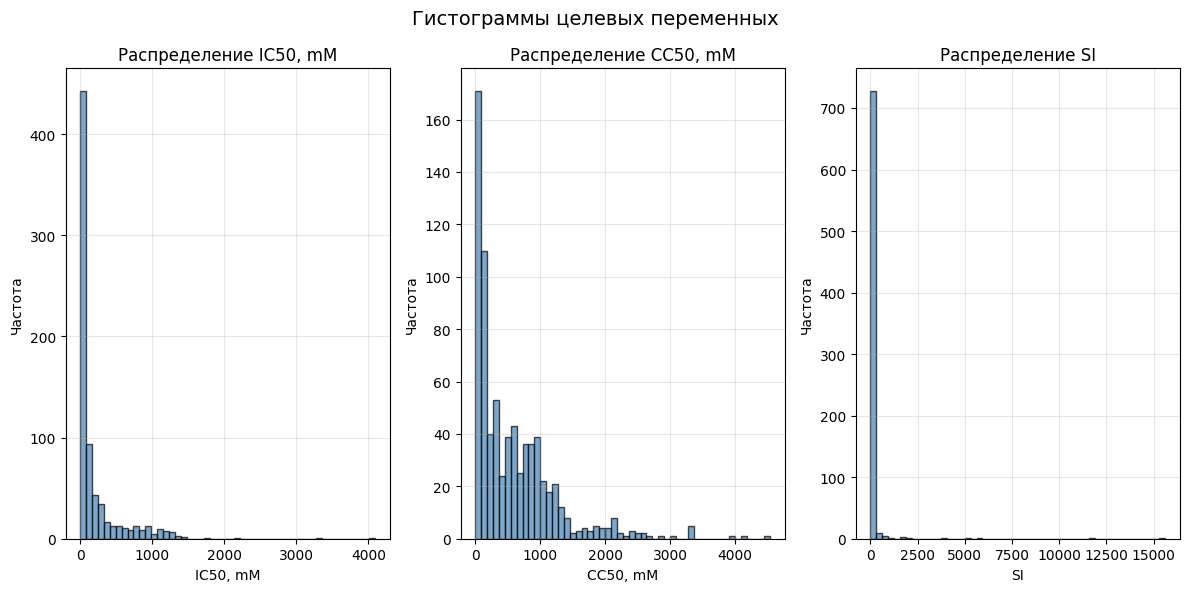

In [101]:
# Строим гистограммы распределений целевых переменных
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes = axes.flatten()

for idx, target in enumerate(target_cols):
    # Гистограмма
    axes[idx].hist(train_df[target], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Распределение {target}', fontsize=12)
    axes[idx].set_xlabel(target)
    axes[idx].set_ylabel('Частота')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Гистограммы целевых переменных', fontsize=14)
plt.tight_layout()
plt.show()

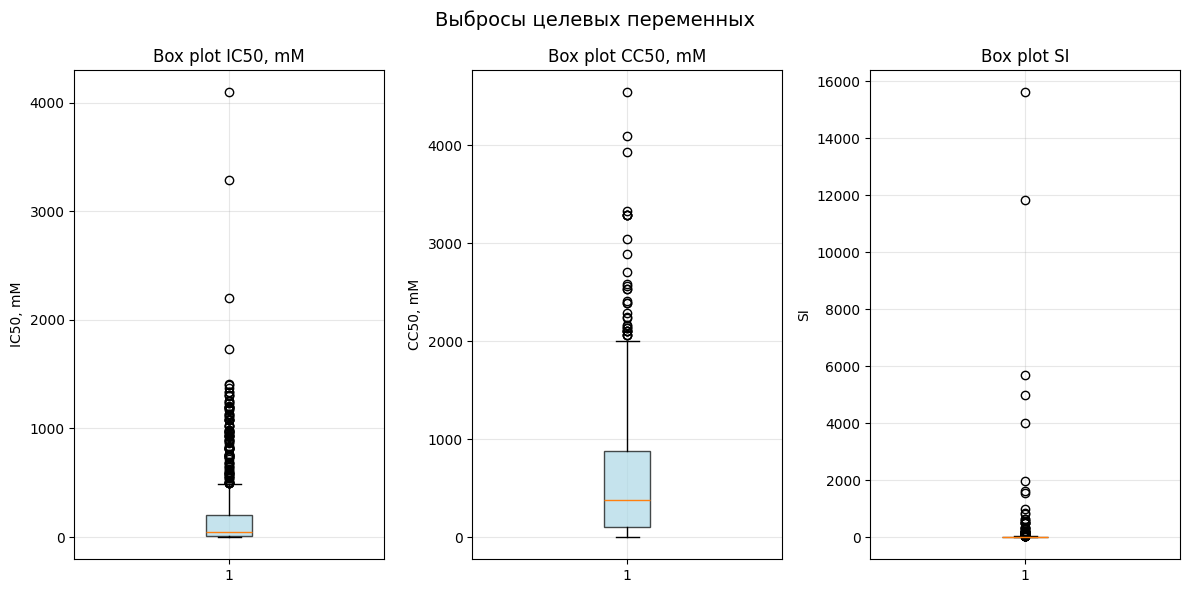

In [102]:
# Строим графики выбросов
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes = axes.flatten()

for idx, target in enumerate(target_cols):
    # Box plot
    axes[idx].boxplot(train_df[target], vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[idx].set_title(f'Box plot {target}', fontsize=12)
    axes[idx].set_ylabel(target)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Выбросы целевых переменных', fontsize=14)
plt.tight_layout()
plt.show()

In [103]:
# Статистика целевых переменных
for target in target_cols:
    Q1 = train_df[target].quantile(0.25)
    Q3 = train_df[target].quantile(0.75)
    IQR = Q3 - Q1
    outliers = train_df[(train_df[target] < Q1 - 1.5*IQR) | (train_df[target] > Q3 + 1.5*IQR)]
    print(f"\n{target}:")
    print(f"  Min: {train_df[target].min():.4f}")
    print(f"  Max: {train_df[target].max():.4f}")
    print(f"  Mean: {train_df[target].mean():.4f}")
    print(f"  Std: {train_df[target].std():.4f}")
    print(f"  Skewness: {train_df[target].skew():.4f}")
    print(f"  Kurtosis: {train_df[target].kurtosis():.4f}")
    print(f"  Выбросов: {len(outliers)} ({len(outliers)/len(train_df)*100:.1f}%)")


IC50, mM:
  Min: 0.0035
  Max: 4095.1886
  Mean: 204.5440
  Std: 370.3679
  Skewness: 3.7874
  Kurtosis: 24.4080
  Выбросов: 107 (14.2%)

CC50, mM:
  Min: 0.7008
  Max: 4538.9762
  Mean: 577.4261
  Std: 641.5152
  Skewness: 2.0563
  Kurtosis: 6.0954
  Выбросов: 32 (4.3%)

SI:
  Min: 0.0115
  Max: 15620.6000
  Mean: 89.1533
  Std: 788.8822
  Skewness: 15.6350
  Kurtosis: 271.6002
  Выбросов: 91 (12.1%)


In [104]:
# Логарифмическое преобразование целевых переменных

train_df['IC50_log'] = np.log1p(train_df['IC50, mM'])
train_df['CC50_log'] = np.log1p(train_df['CC50, mM'])
train_df['SI_log'] = np.log1p(train_df['SI'])

target_cols_log = ['IC50_log', 'CC50_log', 'SI_log']

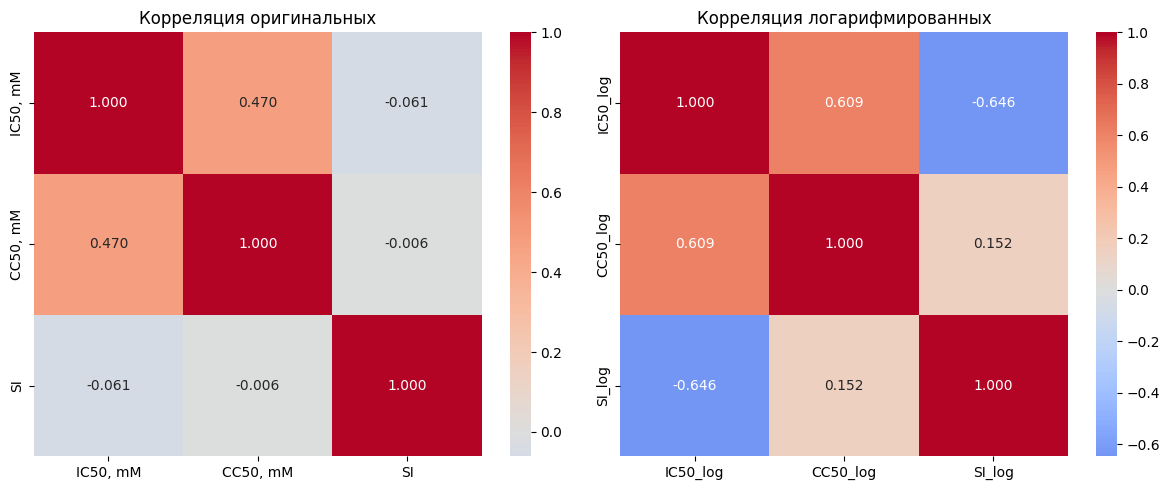

In [105]:
# Корреляция между целевыми переменными

corr_original = train_df[target_cols].corr()
corr_log = train_df[target_cols_log].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(corr_original, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Корреляция оригинальных', fontsize=12)

sns.heatmap(corr_log, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Корреляция логарифмированных', fontsize=12)

plt.tight_layout()
plt.show()

In [106]:
# Анализ признаков
feature_cols = [col for col in train_df.columns 
                if col not in target_cols + target_cols_log + ['index']]

print(f"Всего признаков: {len(feature_cols)}")

# Разделение на типы признаков
binary_features = []
numeric_features = []

for col in feature_cols:
    if train_df[col].nunique() == 2:
        binary_features.append(col)
    else:
        numeric_features.append(col)

print(f"Бинарные признаки: {len(binary_features)}")
print(f"Числовые признаки: {len(numeric_features)}")

# Статистика числовых признаков
numeric_stats = train_df[numeric_features].describe().T
numeric_stats['skew'] = train_df[numeric_features].skew()
numeric_stats['kurtosis'] = train_df[numeric_features].kurtosis()

# Количество признаков с разной скошенностью
high_skew = (numeric_stats['skew'].abs() > 1).sum()
medium_skew = ((numeric_stats['skew'].abs() > 0.5) & (numeric_stats['skew'].abs() <= 1)).sum()
low_skew = (numeric_stats['skew'].abs() <= 0.5).sum()

print(f"Сильная скошенность: {high_skew} признаков")
print(f"Умеренная скошенность: {medium_skew} признаков")
print(f"Нормальное распределение: {low_skew} признаков")

Всего признаков: 210
Бинарные признаки: 31
Числовые признаки: 179
Сильная скошенность: 118 признаков
Умеренная скошенность: 32 признаков
Нормальное распределение: 29 признаков


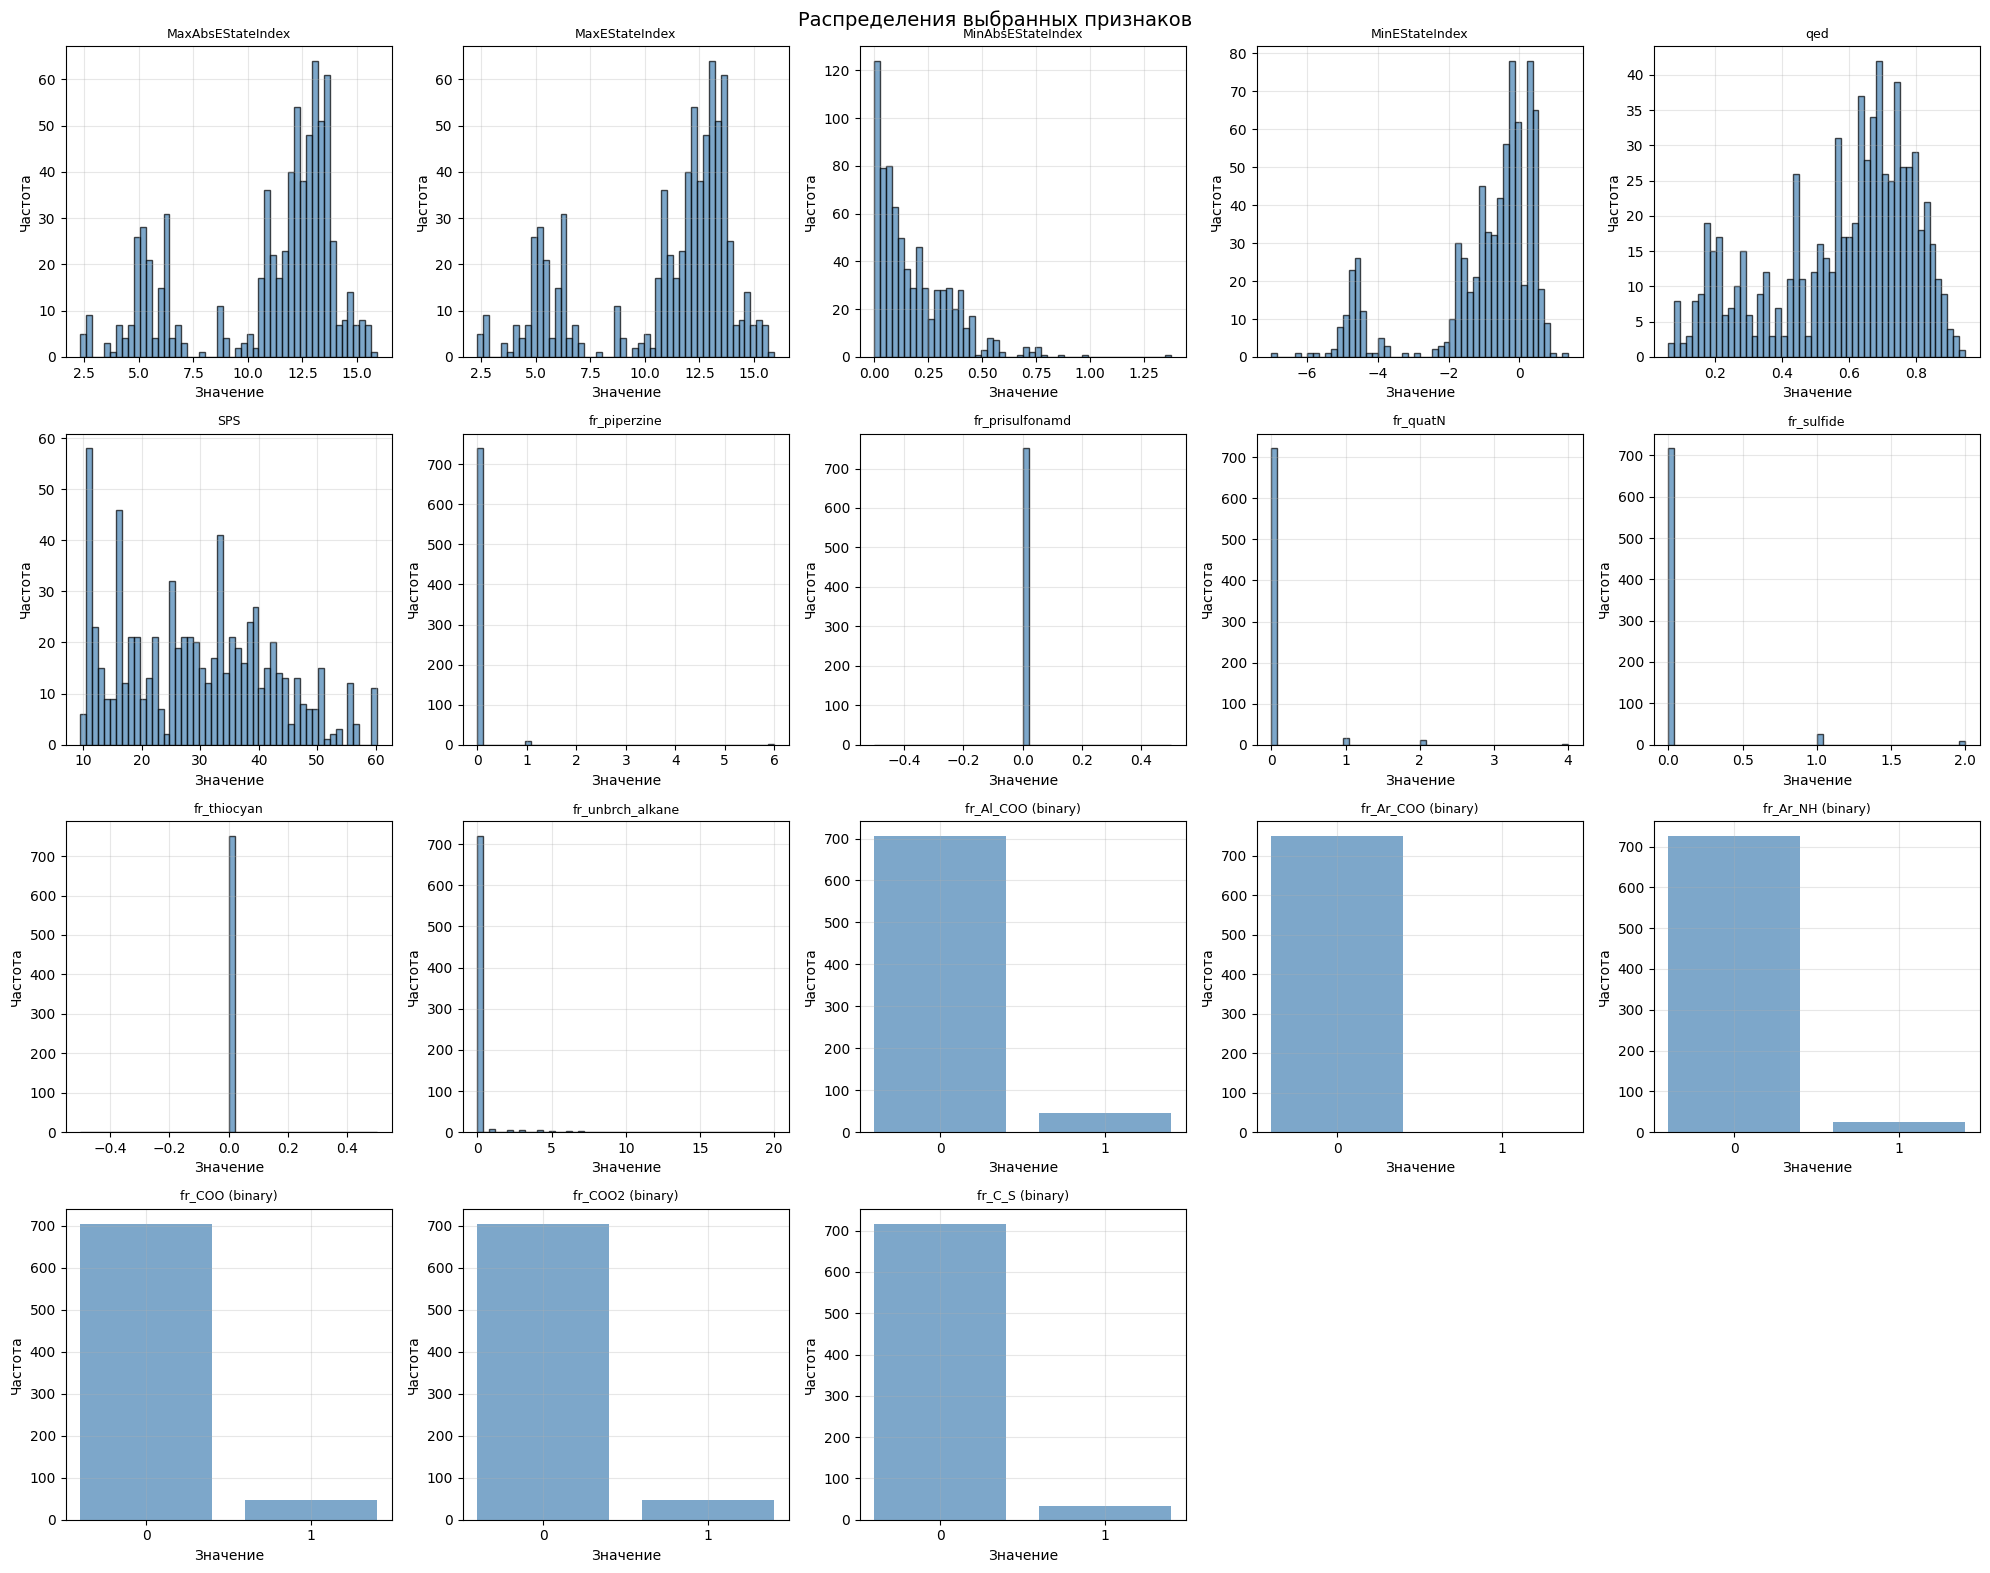

In [107]:
# Визуализация распределений признаков

sample_features = numeric_features[:6] + numeric_features[-6:] + binary_features[:6]

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for idx, feat in enumerate(sample_features[:20]):
    if feat in binary_features:
        counts = train_df[feat].value_counts()
        axes[idx].bar(counts.index.astype(str), counts.values, color='steelblue', alpha=0.7)
        axes[idx].set_title(f'{feat} (binary)', fontsize=9)
    else:
        axes[idx].hist(train_df[feat], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
        axes[idx].set_title(feat, fontsize=9)
    axes[idx].set_xlabel('Значение')
    axes[idx].set_ylabel('Частота')
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(sample_features[:20]), 20):
    axes[idx].set_visible(False)

plt.suptitle('Распределения выбранных признаков', fontsize=14)
plt.tight_layout()
plt.show()

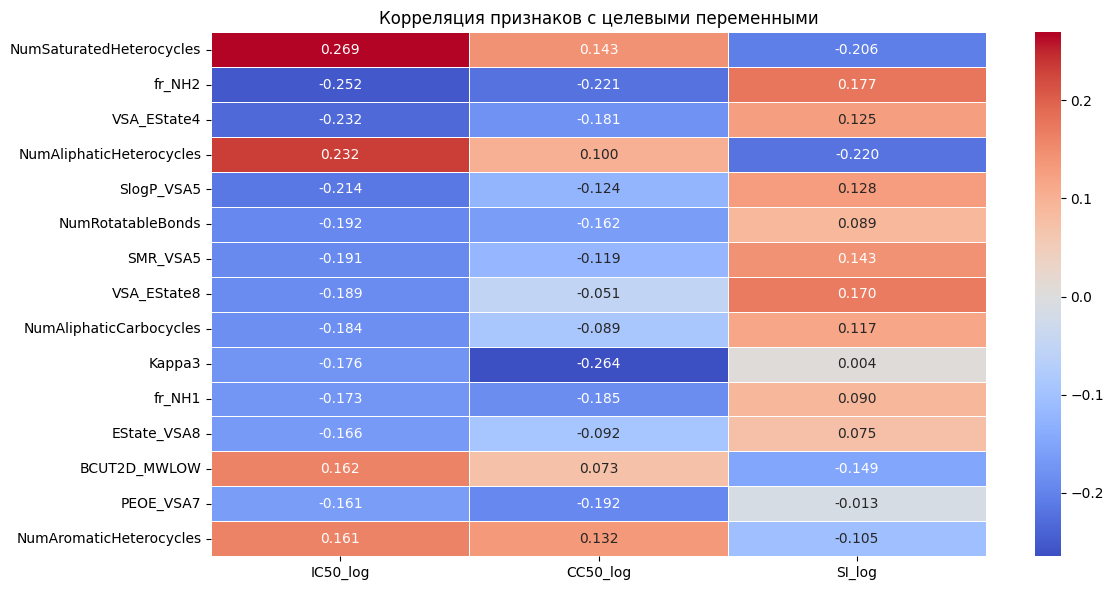

In [108]:
# Корреляционный анализ признаков

corr_with_target = pd.DataFrame(index=feature_cols)

for target in target_cols_log:
    corr_with_target[target] = train_df[feature_cols].corrwith(train_df[target])

plt.figure(figsize=(12, 6))
top_features = corr_with_target['IC50_log'].abs().sort_values(ascending=False).head(15).index
sns.heatmap(corr_with_target.loc[top_features], annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', linewidths=0.5)
plt.title('Корреляция признаков с целевыми переменными', fontsize=12)
plt.tight_layout()
plt.show()

### Выводы

1. Целевые переменные
Анализ целевых переменных (IC50, CC50, SI) выявил проблемы с распределениями. Все три показателя имеют сильную скошенность. Доля выбросов составляет 14,2% для IC50, 4,3% для CC50 и 12,1% для SI. Корреляционный анализ показал умеренную положительную связь между IC50 и CC50, тогда как SI практически не коррелирует с ними. Это объясняется тем, что SI = CC50 / IC50, и малые значения IC50 порождают экстремально большие значения SI.

2. Признаки
Из 210 признаков 31 являются бинарными, а 179 - числовыми молекулярными дескрипторами. Большинство числовых признаков имеют сильную скошенность, 32 признака - умеренную, и только 29 признаков имеют распределение, близкое к нормальному. Это указывает на необходимость преобразования признаков перед обучением моделей.

3. Ключевые выводы и рекомендации
- Логарифмическое преобразование целевых переменных обязательно.

- Масштабирование признаков необходимо. Рекомендуется использовать RobustScaler.

- Преобразование скошенных признаков. Для числовых признаков с сильной скошенностью целесообразно применить логарифмическое или Yeo-Johnson преобразование.

- Бинарные признаки можно использовать без преобразования.

### 3. Предобработка данных

In [109]:
# Определяем признаки и целевые переменные
feature_cols = [col for col in train_df.columns 
                if col not in ['index'] + target_cols + target_cols_log]

print(f"Всего признаков: {len(feature_cols)}")

# Разделяем на числовые и бинарные признаки
binary_cols = []
numeric_cols = []

for col in feature_cols:
    if train_df[col].nunique() == 2:
        binary_cols.append(col)
    else:
        numeric_cols.append(col)

Всего признаков: 210


In [110]:
# Обработка пропусков
# Для числовых признаков заполняем медианой
imputer_num = SimpleImputer(strategy='median')
train_df[numeric_cols] = imputer_num.fit_transform(train_df[numeric_cols])
test_df[numeric_cols] = imputer_num.transform(test_df[numeric_cols])

# Для бинарных признаков заполняем модой
imputer_bin = SimpleImputer(strategy='most_frequent')
train_df[binary_cols] = imputer_bin.fit_transform(train_df[binary_cols])
test_df[binary_cols] = imputer_bin.transform(test_df[binary_cols])

In [111]:
# Преобразование скошенных числовых признаков

# Определяем сильно скошенные признаки
skewness = train_df[numeric_cols].skew()
high_skew_cols = skewness[abs(skewness) > 1].index.tolist()
print(f"Сильно скошенных признаков: {len(high_skew_cols)}")

# Применяем Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson', standardize=False)
train_df[high_skew_cols] = pt.fit_transform(train_df[high_skew_cols])
test_df[high_skew_cols] = pt.transform(test_df[high_skew_cols])

Сильно скошенных признаков: 118


In [112]:
# Масштабирование признаков

# Используем RobustScaler
scaler = RobustScaler()

# Масштабируем числовые признаки
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

In [113]:
# Подготовка данных для обучения

# Признаки для обучения
X = train_df[feature_cols].values
X_test = test_df[feature_cols].values

# Целевые переменные
y_IC50 = train_df['IC50_log'].values
y_CC50 = train_df['CC50_log'].values
y_SI = train_df['SI_log'].values

print(f"X_train shape: {X.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_IC50 shape: {y_IC50.shape}")
print(f"y_CC50 shape: {y_CC50.shape}")
print(f"y_SI shape: {y_SI.shape}")

X_train shape: (751, 210)
X_test shape: (250, 210)
y_IC50 shape: (751,)
y_CC50 shape: (751,)
y_SI shape: (751,)


### Выводы

1. Отбор признаков
Из исходного набора данных были выделены признаки для обучения. Всего использовано 210 признаков, которые разделены на две категории: 31 бинарный признак и 179 числовых признаков.

2. Обработка пропусков
В данных обнаружены пропуски в 12 колонках. Для их устранения:

- Числовые признаки заполнены медианным значением

- Бинарные признаки заполнены модой

3. Преобразование скошенных признаков
Выявлено 118 сильно скошенных признаков. Для нормализации их распределений применено Yeo-Johnson преобразование.

4. Масштабирование признаков
Для приведения признаков к единому масштабу использован RobustScaler. Выбор обусловлен наличием выбросов в данных

5. Преобразование целевых переменных
Целевые переменные IC50, CC50 и SI имеют сильную скошенность. Для улучшения качества моделей применено логарифмическое преобразование

### 4. Выбор лучшей модели

In [114]:
# Метрика RMSE
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Настройки кросс-валидации
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(rmse_score)

# Модели
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'KNN': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
    'NGBoost': NGBRegressor(n_estimators=100, learning_rate=0.01, random_state=42, verbose=0)
}

# Результаты для каждого таргета
results = {target: {} for target in ['IC50', 'CC50', 'SI']}

print("Результаты кросс-валидации (RMSE):")

for target_name, y in [('IC50', y_IC50), ('CC50', y_CC50), ('SI', y_SI)]:
    for model_name, model in models.items():
        try:
            scores = cross_val_score(model, X, y, cv=kfold, scoring=scorer, n_jobs=-1)
            results[target_name][model_name] = {
                'mean': scores.mean(),
                'std': scores.std()
            }
            print(f"{model_name:20} RMSE: {scores.mean():.4f}")
        except Exception as e:
            print(f"{model_name:20} Ошибка: {str(e)[:50]}")

Результаты кросс-валидации (RMSE):
Linear Regression    RMSE: 1.8565
Ridge                RMSE: 1.6020
Lasso                RMSE: 1.5643
KNN                  RMSE: 1.5276
SVR                  RMSE: 1.4866
Random Forest        RMSE: 1.4503
Gradient Boosting    RMSE: 1.4528
XGBoost              RMSE: 1.5278
LightGBM             RMSE: 1.4820
NGBoost              RMSE: 1.5678
Linear Regression    RMSE: 1.6871
Ridge                RMSE: 1.3762
Lasso                RMSE: 1.3414
KNN                  RMSE: 1.3411
SVR                  RMSE: 1.3029
Random Forest        RMSE: 1.2352
Gradient Boosting    RMSE: 1.2491
XGBoost              RMSE: 1.2832
LightGBM             RMSE: 1.2524
NGBoost              RMSE: 1.3391
Linear Regression    RMSE: 1.5548
Ridge                RMSE: 1.3488
Lasso                RMSE: 1.3373
KNN                  RMSE: 1.3099
SVR                  RMSE: 1.3031
Random Forest        RMSE: 1.2205
Gradient Boosting    RMSE: 1.2513
XGBoost              RMSE: 1.3025
LightGBM     


Лучшие модели для каждого таргета:
  IC50: Random Forest (RMSE=1.4503)
  CC50: Random Forest (RMSE=1.2352)
  SI: Random Forest (RMSE=1.2205)


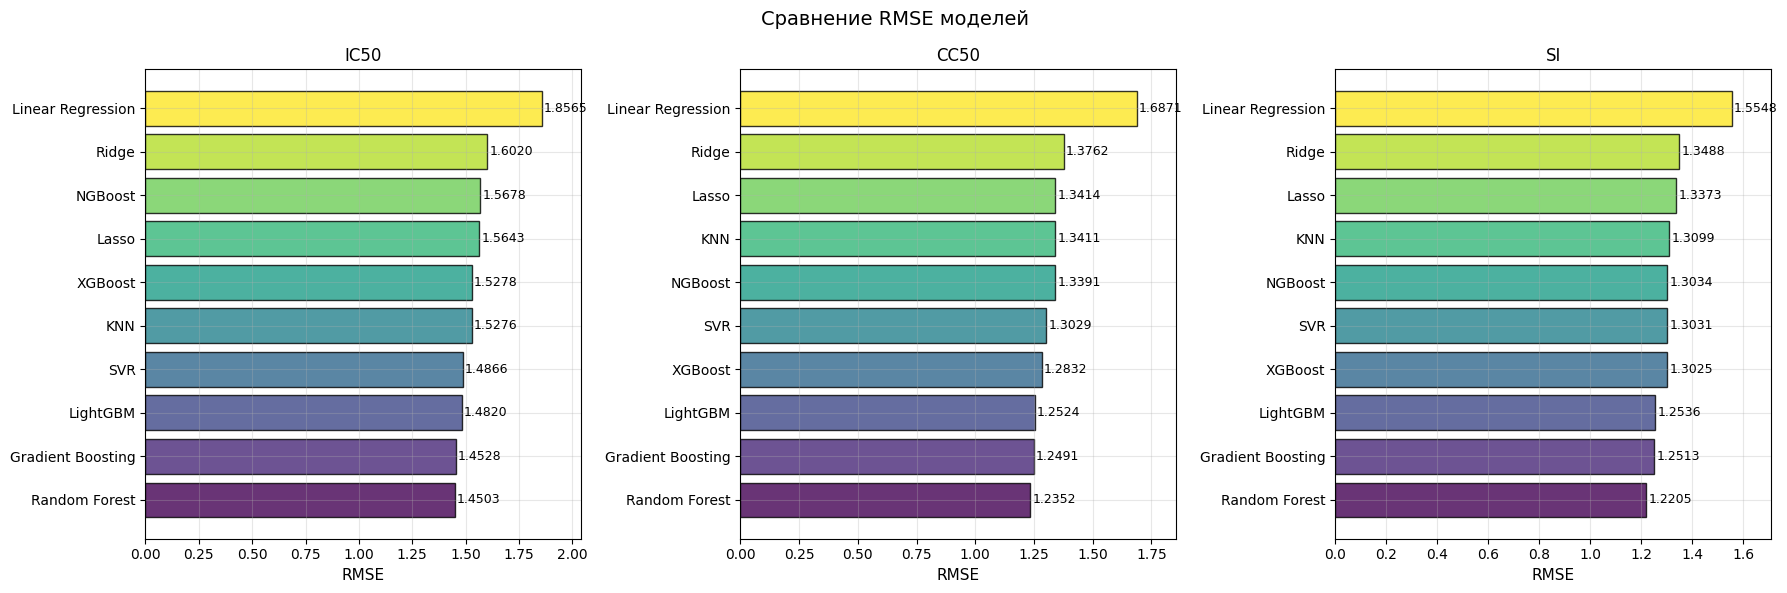

In [115]:
# Визуализация
comparison = []
for target in ['IC50', 'CC50', 'SI']:
    for model_name, metrics in results[target].items():
        comparison.append({
            'Target': target,
            'Model': model_name,
            'RMSE': metrics['mean'],
            'Std': metrics['std']
        })

df_comparison = pd.DataFrame(comparison)

# Лучшие модели для каждого таргета
print("\nЛучшие модели для каждого таргета:")
for target in ['IC50', 'CC50', 'SI']:
    best = df_comparison[df_comparison['Target'] == target].nsmallest(1, 'RMSE')
    print(f"  {target}: {best.iloc[0]['Model']} (RMSE={best.iloc[0]['RMSE']:.4f})")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, target in enumerate(['IC50', 'CC50', 'SI']):
    ax = axes[idx]
    data = df_comparison[df_comparison['Target'] == target].sort_values('RMSE')
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(data)))
    bars = ax.barh(data['Model'], data['RMSE'], color=colors, alpha=0.8, edgecolor='black')
    ax.set_xlabel('RMSE', fontsize=11)
    ax.set_title(f'{target}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, data['RMSE'].max() * 1.1)
    
    for i, (bar, val) in enumerate(zip(bars, data['RMSE'])):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Сравнение RMSE моделей', fontsize=14)
plt.tight_layout()
plt.show()

In [116]:
# Выбор гиперпараметров лучшей модели

# Параметры для Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5]
}

best_rf_models = {}
best_params_all = {}

for target_name, y in [('IC50', y_IC50), ('CC50', y_CC50), ('SI', y_SI)]:
    
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    
    grid_search = GridSearchCV(
        rf, param_grid_rf, cv=3, scoring=scorer, 
        n_jobs=-1, verbose=0
    )
    grid_search.fit(X, y)
    
    best_rf_models[target_name] = grid_search.best_estimator_
    best_params_all[target_name] = grid_search.best_params_
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший RMSE: {grid_search.best_score_:.4f}")

Лучшие параметры: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Лучший RMSE: 1.4789
Лучшие параметры: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Лучший RMSE: 1.2646
Лучшие параметры: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 500}
Лучший RMSE: 1.2436


### Выводы

На основе результатов кросс-валидации было установлено, что Random Forest показывает наилучшие результаты для всех трёх целевых переменных по сравнению с линейными моделями и градиентным бустингом.

Для оптимизации гиперпараметров Random Forest использован GridSearchCV с 3-кратной кросс-валидацией. Оптимизировались следующие параметры: количество деревьев, максимальная глубина дерева  и минимальное количество образцов для разделения узла.

### 5. Предсказание

In [117]:
#Финальное обучение моделей
final_models = {}

best_params = {
    'IC50': {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10},
    'CC50': {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 10},
    'SI': {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 10}
}

for target_name, y in [('IC50', y_IC50), ('CC50', y_CC50), ('SI', y_SI)]:
    model = RandomForestRegressor(
        **best_params[target_name],
        random_state=42,
        n_jobs=-1
    )
    model.fit(X, y)
    final_models[target_name] = model

In [118]:
# Предсказание на тестовой выборке

predictions_log = {}
for target_name, model in final_models.items():
    predictions_log[target_name] = model.predict(X_test)

# Обратное преобразование
pred_IC50 = np.expm1(predictions_log['IC50'])
pred_CC50 = np.expm1(predictions_log['CC50'])
pred_SI = np.expm1(predictions_log['SI'])

In [119]:
# Сохранение файла
submission = pd.DataFrame({
    'index': test_df['index'].values if 'index' in test_df.columns else range(len(pred_IC50)),
    'IC50': pred_IC50, 
    'CC50': pred_CC50, 
    'SI': pred_SI
})

# Округляем до 6 знаков
submission[['IC50', 'CC50', 'SI']] = submission[['IC50', 'CC50', 'SI']].round(6)

# Ограничиваем значения
submission['IC50'] = submission['IC50'].clip(lower=0)
submission['CC50'] = submission['CC50'].clip(lower=0)
submission['SI'] = submission['SI'].clip(lower=0)

submission.to_csv('submission.csv', index=False)

### Общий вывод

В ходе выполнения данной работы была решена задача предсказания трёх целевых показателей химических соединений IC50, CC50 и SI на основе 214 молекулярных дескрипторов. 

1. Разведывательный анализ данных (EDA)

Анализ данных показал, что все три целевые переменные имеют сильную скошенность и содержат значительное количество выбросов. Корреляционный анализ выявил умеренную положительную связь между IC50 и CC50, тогда как SI практически не коррелирует с ними, что объясняется его определением как отношения CC50 к IC50.

Из 210 признаков 31 являются бинарными, а 179 - числовыми молекулярными дескрипторами. Большинство числовых признаков имеют сильную скошенность, что потребовало преобразования данных.

2. Предобработка данных

Была проведена комплексная предобработка данных: пропуски в 12 колонках заполнены медианными значениями для числовых признаков и модой для бинарных; к 118 сильно скошенным признакам применено Yeo-Johnson преобразование; выполнено масштабирование числовых признаков с помощью RobustScaler (устойчив к выбросам); целевые переменные преобразованы с помощью логарифмирования для нормализации распределений. В результате предобработки данные стали пригодными для обучения моделей машинного обучения.

3. Выбор и обучение моделей

Было протестировано девять моделей машинного обучения: линейная регрессия, Ridge, Lasso, KNN, SVR, Random Forest, Gradient Boosting, XGBoost и LightGBM. Оценка качества проводилась с помощью 5-кратной кросс-валидации по метрике RMSE.

Лучшие результаты показала модель Random Forest

Для оптимизации гиперпараметров Random Forest использован GridSearchCV с 3-кратной кросс-валидацией. 

4. Направления для улучшения

Для повышения качества предсказаний и улучшения позиции в рейтинге можно рекомендовать:

- использование ансамбля моделей (CatBoost + XGBoost + Random Forest);

- более глубокую оптимизацию гиперпараметров с помощью RandomizedSearchCV;

- добавление новых признаков на основе взаимодействия существующих;

- применение нейросетевых подходов для молекулярных данных.